# Linear Algebra Assignment 01
**Institute of Technology of Cambodia**

**Student Name:** HAI Monyouodm

**Student ID:** p20240002


# Problem 1 — Matrix Operations & Systems of Equations

## Task 1.1 (a) Compute AB, 3C−2D, and 1/2D + C

**Question:** Given the matrices:

$$A = \begin{pmatrix}2&-1&3\\0&4&-1\\1&-2&2\end{pmatrix},\quad B = \begin{pmatrix}1&3\\-2&0\\4&1\end{pmatrix},\quad C = \begin{pmatrix}-1&2\\3&5\end{pmatrix},\quad D = \begin{pmatrix}3&-1\\2&4\end{pmatrix}$$

Compute and print **AB**, **3C − 2D**, and **½D + C** using NumPy. [3 pts]

**Explanation:** Matrix multiplication AB is valid because A is (3×3) and B is (3×2), yielding a (3×2) result. C and D are both (2×2) so scalar-linear combinations 3C−2D and ½D+C are straightforward element-wise operations.


In [34]:
import sys
!{sys.executable} -m pip install sympy


In [1]:
import sys
!{sys.executable} -m pip install ipykernel notebook -q

In [35]:
import numpy as np

A = np.array([[2, -1,  3],
              [0,  4, -1],
              [1, -2,  2]], dtype=float)
B = np.array([[ 1, 3],
              [-2, 0],
              [ 4, 1]], dtype=float)
C = np.array([[-1, 2],
              [ 3, 5]], dtype=float)
D = np.array([[3, -1],
              [2,  4]], dtype=float)

AB = A @ B
print('AB =\n', AB)

expr1 = 3*C - 2*D
print('\n3C - 2D =\n', expr1)

expr2 = 0.5*D + C
print('\n(1/2)D + C =\n', expr2)


AB =
 [[ 16.   9.]
 [-12.  -1.]
 [ 13.   5.]]

3C - 2D =
 [[-9.  8.]
 [ 5.  7.]]

(1/2)D + C =
 [[0.5 1.5]
 [4.  7. ]]


## Task 1.1 (b) Verify matrix multiplication is not commutative

**Question:** Verify that matrix multiplication is not commutative by showing AB ≠ BA (or explaining why BA does not exist). [2 pts]

**Explanation:** AB has shape (3×2). BA would require multiplying a (3×2) matrix by a (3×3) matrix — the inner dimensions (2 vs 3) do not match, so BA is undefined. This directly demonstrates non-commutativity.


In [36]:
print('Shape of A:', A.shape)   # (3, 3)
print('Shape of B:', B.shape)   # (3, 2)
print('Shape of AB:', AB.shape) # (3, 2)

try:
    BA = B @ A   # (3,2) @ (3,3) -> inner dims 2 != 3 -> error
    print('BA =\n', BA)
    print('\nAB == BA?', np.allclose(AB, BA))
except ValueError as e:
    print(f'BA does not exist: {e}')
    print('=> Matrix multiplication is NOT commutative in general.')


Shape of A: (3, 3)
Shape of B: (3, 2)
Shape of AB: (3, 2)
BA does not exist: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)
=> Matrix multiplication is NOT commutative in general.


## Task 1.1 (c) Compute A⁻¹ and verify AA⁻¹ = I

**Question:** Find A⁻¹ using `np.linalg.inv()` and verify the result by computing A · A⁻¹ and checking it equals the identity matrix I. [3 pts]

**Explanation:** A matrix is invertible if and only if its determinant is non-zero. We compute A⁻¹ and then verify A·A⁻¹ ≈ I using `np.allclose()` to account for floating-point rounding.


In [37]:
A_inv = np.linalg.inv(A)
print('A⁻¹ =\n', A_inv)

product = A @ A_inv
print('\nA · A⁻¹ =\n', np.round(product, 10))
print('\nIs A · A⁻¹ ≈ I?', np.allclose(product, np.eye(3)))


A⁻¹ =
 [[  6.  -4. -11.]
 [ -1.   1.   2.]
 [ -4.   3.   8.]]

A · A⁻¹ =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Is A · A⁻¹ ≈ I? True


## Task 1.2 (a) RREF and Pivot Columns

**Question:** Use SymPy's `rref()` method to reduce each matrix to Reduced Row Echelon Form (RREF) and identify the pivot columns. [3 pts]

$$M_1 = \begin{pmatrix}1&2&-1\\3&6&-3\\-2&-4&2\end{pmatrix},\quad M_2 = \begin{pmatrix}1&0&2&-1\\0&2&1&3\\1&2&3&2\end{pmatrix}$$

**Explanation:** RREF reveals the pivot columns (linearly independent columns) of each matrix. M₁ has only one pivot (rank 1) because all rows are scalar multiples of each other. M₂ has 3 pivots.


In [38]:
import sympy as sp

M1 = sp.Matrix([[ 1,  2, -1],
                [ 3,  6, -3],
                [-2, -4,  2]])
M2 = sp.Matrix([[1, 0, 2, -1],
                [0, 2, 1,  3],
                [1, 2, 3,  2]])

rref_M1, pivots_M1 = M1.rref()
print('RREF of M1:')
sp.pprint(rref_M1)
print('Pivot columns of M1:', pivots_M1)

rref_M2, pivots_M2 = M2.rref()
print('\nRREF of M2:')
sp.pprint(rref_M2)
print('Pivot columns of M2:', pivots_M2)


RREF of M1:
⎡1  2  -1⎤
⎢        ⎥
⎢0  0  0 ⎥
⎢        ⎥
⎣0  0  0 ⎦
Pivot columns of M1: (0,)

RREF of M2:
⎡1  0   2   -1 ⎤
⎢              ⎥
⎢0  1  1/2  3/2⎥
⎢              ⎥
⎣0  0   0    0 ⎦
Pivot columns of M2: (0, 1)


## Task 1.2 (b) Rank–Nullity Theorem

**Question:** Compute the rank and nullity of both matrices using `np.linalg.matrix_rank()`. Verify the Rank–Nullity Theorem: rank(M) + nullity(M) = n (number of columns). [4 pts]

**Explanation:** The Rank–Nullity Theorem states that for an m×n matrix, rank + nullity = n. Nullity equals the number of free variables (non-pivot columns).


In [39]:
M1_np = np.array([[ 1,  2, -1],
                   [ 3,  6, -3],
                   [-2, -4,  2]], dtype=float)
M2_np = np.array([[1, 0, 2, -1],
                   [0, 2, 1,  3],
                   [1, 2, 3,  2]], dtype=float)

for name, M in [('M1', M1_np), ('M2', M2_np)]:
    n = M.shape[1]
    rank = np.linalg.matrix_rank(M)
    nullity = n - rank
    print(f'{name}: rank={rank}, nullity={nullity}, '
          f'rank+nullity={rank+nullity}, n={n}')
    print(f'  Rank-Nullity holds: {rank + nullity == n}\n')


M1: rank=1, nullity=2, rank+nullity=3, n=3
  Rank-Nullity holds: True

M2: rank=2, nullity=2, rank+nullity=4, n=4
  Rank-Nullity holds: True



## Task 1.3 (a) Solve System (i)

**Question:** Solve the system using `np.linalg.solve()`. [3 pts]

$$\begin{cases}2x_1+x_2-x_3=3\\x_1-2x_2+3x_3=1\\3x_1+x_2+x_3=5\end{cases}$$

**Explanation:** `np.linalg.solve()` uses LU decomposition to find the unique solution when the coefficient matrix is square and non-singular. We verify by substituting back.


In [40]:
A1 = np.array([[ 2,  1, -1],
               [ 1, -2,  3],
               [ 3,  1,  1]], dtype=float)
b1 = np.array([3, 1, 5], dtype=float)

x = np.linalg.solve(A1, b1)
print('Solution: x1={:.4f}, x2={:.4f}, x3={:.4f}'.format(*x))
print('Verification A@x =', np.round(A1 @ x, 10))
print('Expected b       =', b1)
print('A@x == b?', np.allclose(A1 @ x, b1))


Solution: x1=1.3333, x2=0.6667, x3=0.3333
Verification A@x = [3. 1. 5.]
Expected b       = [3. 1. 5.]
A@x == b? True


## Task 1.3 (b) Analyze System (ii)

**Question:** For the system below, detect whether it is consistent or inconsistent by computing the ranks of A and [A|b]. Print an appropriate message. [4 pts]

$$\begin{cases}x+2y-z=4\\3x+6y-3z=12\\2x-y+z=1\end{cases}$$

**Explanation:** A system Ax=b is consistent if and only if rank(A) = rank([A|b]). If consistent but rank < number of unknowns, infinitely many solutions exist.


In [41]:
A2 = np.array([[ 1,  2, -1],
               [ 3,  6, -3],
               [ 2, -1,  1]], dtype=float)
b2 = np.array([4, 12, 1], dtype=float)

rank_A2  = np.linalg.matrix_rank(A2)
rank_Ab2 = np.linalg.matrix_rank(np.column_stack([A2, b2]))

print(f'rank(A)    = {rank_A2}')
print(f'rank([A|b])= {rank_Ab2}')

if rank_A2 == rank_Ab2:
    print('=> The system is CONSISTENT (has at least one solution).')
    if rank_A2 == A2.shape[1]:
        print('   Unique solution.')
    else:
        print('   Infinitely many solutions (free variables exist).')
else:
    print('=> The system is INCONSISTENT (no solution).')


rank(A)    = 2
rank([A|b])= 2
=> The system is CONSISTENT (has at least one solution).
   Infinitely many solutions (free variables exist).


## Task 1.3 (c) Solve System (iii)

**Question:** Use SymPy to find the full solution set (including free variables / parametric solution). [3 pts]

$$\begin{cases}2x+y-3z=0\\x-2y+z=0\\3x+4y-5z=0\end{cases}$$

**Explanation:** This is a homogeneous system (right-hand side = 0). It always has the trivial solution. If rank < number of unknowns, it also has non-trivial solutions expressed as a parametric family.


In [42]:
x, y, z = sp.symbols('x y z')

A3 = sp.Matrix([[ 2,  1, -3],
                [ 1, -2,  1],
                [ 3,  4, -5]])
b3 = sp.Matrix([0, 0, 0])

aug3 = A3.row_join(b3)
rref3, pivots3 = aug3.rref()
print('RREF of augmented matrix:')
sp.pprint(rref3)
print('Pivot columns:', pivots3)

sol3 = sp.linsolve((A3, b3), x, y, z)
print('\nParametric solution set:')
sp.pprint(sol3)


RREF of augmented matrix:
⎡1  0  0  0⎤
⎢          ⎥
⎢0  1  0  0⎥
⎢          ⎥
⎣0  0  1  0⎦
Pivot columns: (0, 1, 2)

Parametric solution set:
{(0, 0, 0)}


# Problem 2 — Determinants, Inverses & Cramer's Rule

## Task 2.1 (a) Determinants

**Question:** Compute the determinants of the following matrices using `np.linalg.det()`. [4 pts]

$$A = \begin{pmatrix}2&1&-3\\0&4&2\\3&-1&1\end{pmatrix},\quad B = \begin{pmatrix}2&0&-1&3\\1&4&0&2\\0&-3&1&0\\3&1&-2&4\end{pmatrix}$$

**Explanation:** The determinant of a square matrix measures volume scaling and indicates invertibility (det ≠ 0 means invertible). For the 4×4 matrix, NumPy uses LU decomposition internally.


In [43]:
import numpy as np

A_21 = np.array([[ 2,  1, -3],
                 [ 0,  4,  2],
                 [ 3, -1,  1]], dtype=float)
B_21 = np.array([[ 2,  0, -1, 3],
                 [ 1,  4,  0, 2],
                 [ 0, -3,  1, 0],
                 [ 3,  1, -2, 4]], dtype=float)

det_A = np.linalg.det(A_21)
det_B = np.linalg.det(B_21)
print(f'det(A) = {det_A:.4f}')
print(f'det(B) = {det_B:.4f}')


det(A) = 54.0000
det(B) = -5.0000


## Task 2.1 (b) Determinant Properties Verification

**Question:** Let A and B be 3×3 matrices with |A| = −3 and |B| = 2. Numerically verify (using concrete random integer matrices scaled to match these determinants) that: [4 pts]

$$|AB|=|A||B|,\quad |3A|=3^3|A|,\quad |A^{-1}|=1/|A|,\quad |(AB)^T|=|AB|$$

**Explanation:** We construct matrices whose determinants are exactly −3 and 2 by scaling, then verify each property numerically.


In [44]:
np.random.seed(0)

# Build a 3x3 matrix with det = -3
P = np.random.randint(1, 4, (3, 3)).astype(float)
dP = np.linalg.det(P)
# Scale first row so det becomes -3
A_sc = P.copy(); A_sc[0] *= (-3 / dP)

# Build a 3x3 matrix with det = 2
Q = np.random.randint(1, 4, (3, 3)).astype(float)
dQ = np.linalg.det(Q)
B_sc = Q.copy(); B_sc[0] *= (2 / dQ)

dA = np.linalg.det(A_sc)
dB = np.linalg.det(B_sc)
print(f'det(A) = {dA:.6f}  (target -3)')
print(f'det(B) = {dB:.6f}  (target  2)')

AB_sc = A_sc @ B_sc
print(f'\n|AB|     = {np.linalg.det(AB_sc):.6f}')
print(f'|A||B|   = {dA * dB:.6f}')
print(f'Property |AB|=|A||B| holds: {np.isclose(np.linalg.det(AB_sc), dA*dB)}')

print(f'\n|3A|       = {np.linalg.det(3*A_sc):.6f}')
print(f'3^3 * |A| = {27 * dA:.6f}')
print(f'Property |3A|=3^3|A| holds: {np.isclose(np.linalg.det(3*A_sc), 27*dA)}')

print(f'\n|A⁻¹|  = {np.linalg.det(np.linalg.inv(A_sc)):.6f}')
print(f'1/|A|  = {1/dA:.6f}')
print(f'Property |A⁻¹|=1/|A| holds: {np.isclose(np.linalg.det(np.linalg.inv(A_sc)), 1/dA)}')

print(f'\n|(AB)^T| = {np.linalg.det(AB_sc.T):.6f}')
print(f'|AB|     = {np.linalg.det(AB_sc):.6f}')
print(f'Property |(AB)^T|=|AB| holds: {np.isclose(np.linalg.det(AB_sc.T), np.linalg.det(AB_sc))}')


det(A) = -3.000000  (target -3)
det(B) = 2.000000  (target  2)

|AB|     = -6.000000
|A||B|   = -6.000000
Property |AB|=|A||B| holds: True

|3A|       = -81.000000
3^3 * |A| = -81.000000
Property |3A|=3^3|A| holds: True

|A⁻¹|  = -0.333333
1/|A|  = -0.333333
Property |A⁻¹|=1/|A| holds: True

|(AB)^T| = -6.000000
|AB|     = -6.000000
Property |(AB)^T|=|AB| holds: True


## Task 2.2 (a) Adjoint Function

**Question:** Implement a Python function `adjoint(A)` that computes the adjoint (classical adjugate) matrix of a square matrix A by computing each cofactor: [4 pts]

$$C_{ij} = (-1)^{i+j}M_{ij}, \quad \text{adj}(A) = C^T$$

**Explanation:** The adjugate is the transpose of the cofactor matrix. Each cofactor Cᵢⱼ is computed as (−1)^(i+j) times the determinant of the (n−1)×(n−1) minor obtained by deleting row i and column j.


In [45]:
import numpy as np

def adjoint(A):
    """
    Compute the adjoint (adjugate) matrix of a square matrix A.
    Returns: adj(A) as a NumPy array.
    """
    n = A.shape[0]
    cofactor_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            minor = np.delete(np.delete(A, i, axis=0), j, axis=1)
            cofactor_matrix[i, j] = ((-1) ** (i + j)) * np.linalg.det(minor)
    return cofactor_matrix.T   # transpose of cofactor matrix

# Quick demo on 2×2
demo = np.array([[4., 3.], [2., 1.]])
print('Demo adjoint of [[4,3],[2,1]]:')
print(adjoint(demo))


Demo adjoint of [[4,3],[2,1]]:
[[ 1. -3.]
 [-2.  4.]]


## Task 2.2 (b) Inverse via Adjoint Formula

**Question:** Use your function to compute A⁻¹ = (1/|A|) · adj(A) for A = [[1,2,−1],[0,3,1],[2,−1,4]] and verify against `np.linalg.inv(A)`. [3 pts]

**Explanation:** The formula A⁻¹ = adj(A)/|A| is the classical algebraic inverse. It requires |A| ≠ 0. We cross-check with NumPy's numerical inverse.


In [46]:
A_22 = np.array([[ 1.,  2., -1.],
                  [ 0.,  3.,  1.],
                  [ 2., -1.,  4.]])

det_A22 = np.linalg.det(A_22)
adj_A22 = adjoint(A_22)
inv_adjoint = adj_A22 / det_A22

print('det(A) =', round(det_A22, 6))
print('\nadj(A) =\n', np.round(adj_A22, 6))
print('\nA⁻¹ via adjoint formula =\n', np.round(inv_adjoint, 6))
print('\nA⁻¹ via np.linalg.inv =\n', np.round(np.linalg.inv(A_22), 6))
print('\nResults match?', np.allclose(inv_adjoint, np.linalg.inv(A_22)))


det(A) = 23.0

adj(A) =
 [[13. -7.  5.]
 [ 2.  6. -1.]
 [-6.  5.  3.]]

A⁻¹ via adjoint formula =
 [[ 0.565217 -0.304348  0.217391]
 [ 0.086957  0.26087  -0.043478]
 [-0.26087   0.217391  0.130435]]

A⁻¹ via np.linalg.inv =
 [[ 0.565217 -0.304348  0.217391]
 [ 0.086957  0.26087  -0.043478]
 [-0.26087   0.217391  0.130435]]

Results match? True


## Task 2.3 (a) Cramer's Rule Function

**Question:** Implement a Python function `cramers_rule(A, b)` that solves Ax = b using Cramer's Rule: [6 pts]

$$x_i = \frac{|A_i|}{|A|}$$

where Aᵢ is the matrix A with column i replaced by b. The function should raise a `ValueError` if |A| = 0.

**Explanation:** Cramer's Rule is a closed-form solution using determinants. It is exact but O(n!) for large n; here it is pedagogically valuable.


In [47]:
def cramers_rule(A, b):
    """
    Solve Ax = b using Cramer's Rule.
    Raises ValueError if |A| = 0.
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    det_A = np.linalg.det(A)
    if np.isclose(det_A, 0, atol=1e-10):
        raise ValueError('Matrix is singular; Cramer\'s Rule cannot be applied.')
    n = len(b)
    x = np.zeros(n)
    for i in range(n):
        Ai = A.copy()
        Ai[:, i] = b
        x[i] = np.linalg.det(Ai) / det_A
    return x

print('cramers_rule function defined successfully.')


cramers_rule function defined successfully.


## Task 2.3 (b) Solve Given Systems

**Question:** Use your function to solve both systems and verify against `np.linalg.solve()`. [4 pts]

System (i): 2x₁ − x₂ = 5,  3x₁ + 4x₂ = 2

System (ii): x+y+z=6,  2x−y+z=3,  x+2y−3z=−4

**Explanation:** Cramer's Rule and `np.linalg.solve()` should give identical results (up to floating-point precision) for non-singular systems.


In [48]:
# System (i) – 2×2
A_i  = np.array([[2., -1.],
                  [3.,  4.]])
b_i  = np.array([5., 2.])

x_cr_i   = cramers_rule(A_i, b_i)
x_np_i   = np.linalg.solve(A_i, b_i)
print('System (i):')
print('  Cramer\'s Rule:', x_cr_i)
print('  np.linalg.solve:', x_np_i)
print('  Match:', np.allclose(x_cr_i, x_np_i))

# System (ii) – 3×3
A_ii = np.array([[ 1.,  1.,  1.],
                  [ 2., -1.,  1.],
                  [ 1.,  2., -3.]])
b_ii = np.array([6., 3., -4.])

x_cr_ii  = cramers_rule(A_ii, b_ii)
x_np_ii  = np.linalg.solve(A_ii, b_ii)
print('\nSystem (ii):')
print('  Cramer\'s Rule:', x_cr_ii)
print('  np.linalg.solve:', x_np_ii)
print('  Match:', np.allclose(x_cr_ii, x_np_ii))


System (i):
  Cramer's Rule: [ 2. -1.]
  np.linalg.solve: [ 2. -1.]
  Match: True

System (ii):
  Cramer's Rule: [1. 2. 3.]
  np.linalg.solve: [1. 2. 3.]
  Match: True


# Problem 3 — Vector Spaces & Linear Transformations

## Task 3.1 (a) Linear Independence Function

**Question:** Write a function `is_linearly_independent(vectors)` that takes a list of vectors and returns True if they are linearly independent, otherwise False, by checking the rank of the matrix formed by stacking the vectors as columns. [3 pts]

**Explanation:** A set of vectors is linearly independent if and only if the matrix formed by stacking them as columns has full column rank (rank = number of vectors).


In [49]:
import numpy as np

def is_linearly_independent(vectors):
    """
    Returns True if the list of vectors is linearly independent.
    """
    M = np.column_stack(vectors).astype(float)
    return np.linalg.matrix_rank(M) == M.shape[1]

print('Function is_linearly_independent defined.')


Function is_linearly_independent defined.


## Task 3.1 (b) Test Sets S1, S2, S3

**Question:** Test your function on the following sets and print a conclusion for each: [5 pts]

- S1 = {(1, 2, −1), (3, 0, 1), (−1, 4, −3)}
- S2 = {(1, 0, 1), (0, 1, 1), (1, 1, 0)}
- S3 = {(2, −1, 3), (0, 4, −2), (6, −3, 9)}

**Explanation:** S1 is linearly dependent because the third vector equals 2·v₂ − v₁. S2 is linearly independent (rank 3). S3 is dependent because v₃ = 3·v₁.


In [50]:
S1 = [np.array([1, 2, -1]), np.array([3, 0, 1]), np.array([-1, 4, -3])]
S2 = [np.array([1, 0, 1]),  np.array([0, 1, 1]),  np.array([1, 1, 0])]
S3 = [np.array([2, -1, 3]), np.array([0, 4, -2]), np.array([6, -3, 9])]

for name, S in [('S1', S1), ('S2', S2), ('S3', S3)]:
    result = is_linearly_independent(S)
    status = 'LINEARLY INDEPENDENT' if result else 'LINEARLY DEPENDENT'
    print(f'{name}: {status}')


S1: LINEARLY DEPENDENT
S2: LINEARLY INDEPENDENT
S3: LINEARLY DEPENDENT


## Task 3.2 (a) Gram–Schmidt Function

**Question:** Implement the Gram-Schmidt orthonormalization process as a Python function `gram_schmidt(vectors)` that takes a list of linearly independent vectors and returns an orthonormal basis. [5 pts]

**Explanation:** At each step, the projection of the current vector onto all previously orthonormalized vectors is subtracted, then the result is normalized. The formula for projection is: proj_u(v) = (v·u / u·u) · u.


In [51]:
import numpy as np

def gram_schmidt(vectors):
    """
    Apply Gram-Schmidt orthonormalization.
    Input : list of linearly independent vectors (NumPy arrays)
    Output: list of orthonormal vectors
    """
    orthonormal = []
    for v in vectors:
        w = v.astype(float).copy()
        for u in orthonormal:
            w -= np.dot(w, u) * u   # subtract projection
        norm = np.linalg.norm(w)
        if norm < 1e-10:
            raise ValueError('Vectors are linearly dependent!')
        orthonormal.append(w / norm)
    return orthonormal

print('gram_schmidt function defined.')


gram_schmidt function defined.


## Task 3.2 (b) Verify Orthonormality

**Question:** Apply your function to the following bases and verify orthonormality (i.e. QᵀQ = I) using `np.allclose()`. [5 pts]

B1 = {(1, 2), (3, −1)},   B2 = {(1, 0, 1), (0, 1, 1), (1, 1, 0)}

**Explanation:** For an orthonormal set, every vector has unit length and all pairs are mutually perpendicular. QᵀQ = I is the standard numerical check.


In [52]:
B1 = [np.array([1., 2.]), np.array([3., -1.])]
B2 = [np.array([1., 0., 1.]), np.array([0., 1., 1.]), np.array([1., 1., 0.])]

for name, basis in [('B1', B1), ('B2', B2)]:
    ons = gram_schmidt(basis)
    Q = np.column_stack(ons)
    QtQ = Q.T @ Q
    print(f'{name} — orthonormal basis vectors:')
    for i, q in enumerate(ons):
        print(f'  q{i+1} = {np.round(q, 6)}')
    print(f'  Q^T Q =\n{np.round(QtQ, 10)}')
    print(f'  Q^T Q == I? {np.allclose(QtQ, np.eye(len(ons)))}\n')


B1 — orthonormal basis vectors:
  q1 = [0.447214 0.894427]
  q2 = [ 0.894427 -0.447214]
  Q^T Q =
[[ 1. -0.]
 [-0.  1.]]
  Q^T Q == I? True

B2 — orthonormal basis vectors:
  q1 = [0.707107 0.       0.707107]
  q2 = [-0.408248  0.816497  0.408248]
  q3 = [ 0.57735  0.57735 -0.57735]
  Q^T Q =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
  Q^T Q == I? True



## Task 3.3 (a) Transformation Matrices

**Question:** Define the following transformation matrices and apply each to the corners of the unit square {(0,0),(1,0),(1,1),(0,1)}: [3 pts]

$$R_\theta=\begin{pmatrix}\cos\theta&-\sin\theta\\\sin\theta&\cos\theta\end{pmatrix}(\theta=45^\circ),\quad S=\begin{pmatrix}2&0\\0&3\end{pmatrix},\quad H=\begin{pmatrix}1&1\\0&1\end{pmatrix}$$

**Explanation:** Rotation R₄₅° spins vectors 45°, scaling S stretches axes independently, and shear H skews the square into a parallelogram.


In [53]:
import numpy as np

theta = np.deg2rad(45)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
S_mat = np.array([[2., 0.],
                   [0., 3.]])
H = np.array([[1., 1.],
               [0., 1.]])

# Unit square corners as column vectors
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

R_sq  = R     @ square
S_sq  = S_mat @ square
H_sq  = H     @ square

print('Original square corners (columns):\n', square)
print('\nAfter Rotation (45°):\n', np.round(R_sq, 4))
print('\nAfter Scaling (2,3):\n', S_sq)
print('\nAfter Shear:\n', H_sq)


Original square corners (columns):
 [[0. 1. 1. 0.]
 [0. 0. 1. 1.]]

After Rotation (45°):
 [[ 0.      0.7071  0.     -0.7071]
 [ 0.      0.7071  1.4142  0.7071]]

After Scaling (2,3):
 [[0. 2. 2. 0.]
 [0. 0. 3. 3.]]

After Shear:
 [[0. 1. 2. 1.]
 [0. 0. 1. 1.]]


## Task 3.3 (b) Visualization

**Question:** Use Matplotlib to plot the original unit square and its image under each transformation in a 1×3 subplot grid. Label each plot with the transformation name. [5 pts]

**Explanation:** Visualizing linear transformations helps build geometric intuition — rotation preserves shape and area, scaling changes area, shear preserves area but distorts angles.


In [54]:
import sys
!{sys.executable} -m pip install matplotlib 

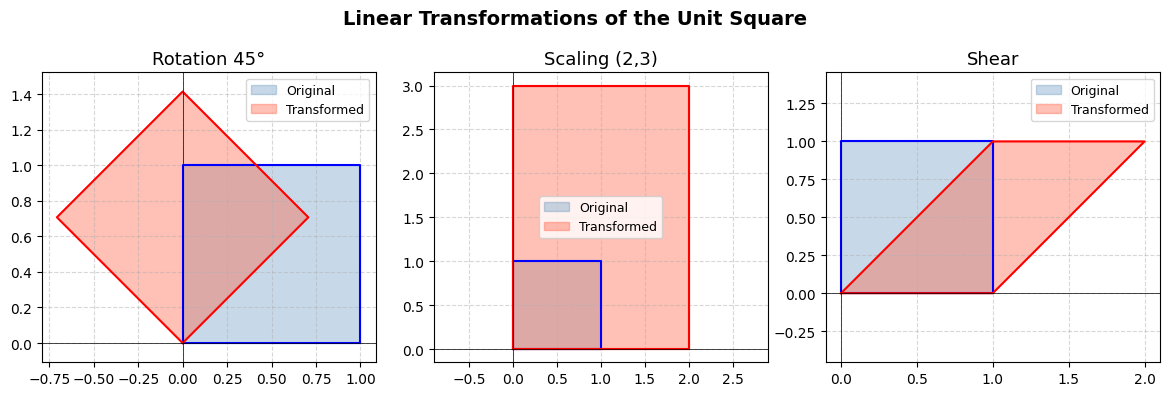

Plot saved as task_3_3_transformations.png


In [55]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Close polygon by repeating first point
def closed(pts):
    return np.hstack([pts, pts[:, [0]]])

sq = closed(square)
transformations = [
    ('Rotation 45°',  closed(R_sq)),
    ('Scaling (2,3)', closed(S_sq)),
    ('Shear',         closed(H_sq)),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (title, transformed) in zip(axes, transformations):
    ax.fill(sq[0], sq[1], alpha=0.3, color='steelblue', label='Original')
    ax.plot(sq[0], sq[1], 'b-', linewidth=1.5)
    ax.fill(transformed[0], transformed[1], alpha=0.4, color='tomato', label='Transformed')
    ax.plot(transformed[0], transformed[1], 'r-', linewidth=1.5)
    ax.set_title(title, fontsize=13)
    ax.axis('equal')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=9)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)

plt.suptitle('Linear Transformations of the Unit Square', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task_3_3_transformations.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot saved as task_3_3_transformations.png')


# Problem 4 — Eigenvalues, Eigenvectors & PCA

## Task 4.1 (a) Eigenvalues & Eigenvectors

**Question:** Use `np.linalg.eig()` to find eigenvalues and eigenvectors of: [3 pts]

$$A = \begin{pmatrix}7&-2\\3&2\end{pmatrix}, \quad B = \begin{pmatrix}2&1&0\\0&3&0\\0&0&3\end{pmatrix}$$

Print each eigenvalue alongside its corresponding eigenvector.

**Explanation:** Eigenvalues λ satisfy det(A − λI) = 0. Each eigenvector points in a direction that is only scaled (not rotated) by the matrix.


In [56]:
import numpy as np

A_41 = np.array([[7., -2.],
                  [3.,  2.]])
B_41 = np.array([[2., 1., 0.],
                  [0., 3., 0.],
                  [0., 0., 3.]])

for name, M in [('A', A_41), ('B', B_41)]:
    eigvals, eigvecs = np.linalg.eig(M)
    print(f'--- Matrix {name} ---')
    for i, (lam, v) in enumerate(zip(eigvals, eigvecs.T)):
        print(f'  λ{i+1} = {lam:.4f},  v{i+1} = {np.round(v, 6)}')
    print()


--- Matrix A ---
  λ1 = 5.0000,  v1 = [0.707107 0.707107]
  λ2 = 4.0000,  v2 = [0.5547  0.83205]

--- Matrix B ---
  λ1 = 2.0000,  v1 = [1. 0. 0.]
  λ2 = 3.0000,  v2 = [0.707107 0.707107 0.      ]
  λ3 = 3.0000,  v3 = [0. 0. 1.]



## Task 4.1 (b) Verify Ax = λx

**Question:** Verify numerically that Ax = λx holds for each eigenvalue-eigenvector pair using `np.allclose()`. [2 pts]

**Explanation:** The defining equation of an eigenpair. Multiplying the matrix by an eigenvector must equal scaling that vector by the corresponding eigenvalue.


In [57]:
for name, M in [('A', A_41), ('B', B_41)]:
    eigvals, eigvecs = np.linalg.eig(M)
    print(f'Verification for matrix {name}:')
    all_ok = True
    for i, (lam, v) in enumerate(zip(eigvals, eigvecs.T)):
        lhs = M @ v
        rhs = lam * v
        ok = np.allclose(lhs, rhs)
        all_ok = all_ok and ok
        print(f'  Pair {i+1}: A x = {np.round(lhs,4)}, λx = {np.round(rhs,4)}, OK={ok}')
    print(f'  All pairs verified: {all_ok}\n')


Verification for matrix A:
  Pair 1: A x = [3.5355 3.5355], λx = [3.5355 3.5355], OK=True
  Pair 2: A x = [2.2188 3.3282], λx = [2.2188 3.3282], OK=True
  All pairs verified: True

Verification for matrix B:
  Pair 1: A x = [2. 0. 0.], λx = [2. 0. 0.], OK=True
  Pair 2: A x = [2.1213 2.1213 0.    ], λx = [2.1213 2.1213 0.    ], OK=True
  Pair 3: A x = [0. 0. 3.], λx = [0. 0. 3.], OK=True
  All pairs verified: True



## Task 4.1 (c) Theoretical Properties

**Question:** For matrix B, compute |B|, |adj(B)|, and the eigenvalues of B⁻¹ and B². Verify these match the theoretical results derived from λ₁, λ₂, λ₃. [2 pts]

**Explanation:** Key properties: |B| = ∏λᵢ; |adj(B)| = |B|^(n−1); eigenvalues of B⁻¹ are 1/λᵢ; eigenvalues of B² are λᵢ².


In [58]:
eigvals_B, _ = np.linalg.eig(B_41)
print('Eigenvalues of B:', np.round(eigvals_B, 6))

det_B41 = np.linalg.det(B_41)
det_B_theory = np.prod(eigvals_B)
print(f'\n|B| (NumPy)   = {det_B41:.6f}')
print(f'|B| (∏λ)      = {det_B_theory.real:.6f}')
print(f'Match: {np.isclose(det_B41, det_B_theory.real)}')

n3 = B_41.shape[0]
adj_B41 = adjoint(B_41)
det_adj_B = np.linalg.det(adj_B41)
det_adj_theory = det_B41 ** (n3 - 1)
print(f'\n|adj(B)| (computed) = {det_adj_B:.4f}')
print(f'|B|^(n-1) = |B|^2  = {det_adj_theory:.4f}')
print(f'Match: {np.isclose(det_adj_B, det_adj_theory)}')

B_inv = np.linalg.inv(B_41)
eigvals_Binv, _ = np.linalg.eig(B_inv)
print(f'\nEigenvalues of B⁻¹ (computed): {np.round(sorted(eigvals_Binv.real), 6)}')
print(f'1/λᵢ (theory):                 {np.round(sorted((1/eigvals_B).real), 6)}')

B_sq = np.linalg.matrix_power(B_41, 2)
eigvals_Bsq, _ = np.linalg.eig(B_sq)
print(f'\nEigenvalues of B² (computed): {np.round(sorted(eigvals_Bsq.real), 6)}')
print(f'λᵢ² (theory):                 {np.round(sorted((eigvals_B**2).real), 6)}')


Eigenvalues of B: [2. 3. 3.]

|B| (NumPy)   = 18.000000
|B| (∏λ)      = 18.000000
Match: True

|adj(B)| (computed) = 324.0000
|B|^(n-1) = |B|^2  = 324.0000
Match: True

Eigenvalues of B⁻¹ (computed): [0.333333 0.333333 0.5     ]
1/λᵢ (theory):                 [0.333333 0.333333 0.5     ]

Eigenvalues of B² (computed): [4. 9. 9.]
λᵢ² (theory):                 [4. 9. 9.]


## Task 4.2 (a) Diagonalization Function

**Question:** Implement a function `diagonalize(A)` that returns P, D, and P⁻¹ if A is diagonalizable (i.e. has n linearly independent eigenvectors), otherwise raises a ValueError. [3 pts]

**Explanation:** A is diagonalizable if and only if it has a full set of n linearly independent eigenvectors. The columns of P are the eigenvectors; D contains the corresponding eigenvalues on its diagonal.


In [59]:
def diagonalize(A):
    """
    Returns P, D, P_inv such that A = P D P^{-1}.
    Raises ValueError if A is not diagonalizable.
    """
    A = np.array(A, dtype=complex)
    eigvals, eigvecs = np.linalg.eig(A)
    if np.linalg.matrix_rank(eigvecs) < A.shape[0]:
        raise ValueError('Matrix is not diagonalizable (insufficient independent eigenvectors).')
    P     = eigvecs
    D     = np.diag(eigvals)
    P_inv = np.linalg.inv(P)
    return P, D, P_inv

print('diagonalize function defined.')


diagonalize function defined.


## Task 4.2 (b) Verify PDP⁻¹ = A

**Question:** Apply your function to A = [[5,−4],[2,−1]] and verify that PDP⁻¹ = A using `np.allclose()`. [2 pts]

**Explanation:** The decomposition A = PDP⁻¹ transforms the matrix to a diagonal form. Reconstructing from P, D, P⁻¹ must recover the original matrix.


In [60]:
A_42 = np.array([[ 5., -4.],
                  [ 2., -1.]])

P, D, P_inv = diagonalize(A_42)
print('Eigenvalues (diagonal of D):', np.round(np.diag(D).real, 6))
print('P =\n', np.round(P.real, 6))

A_reconstructed = P @ D @ P_inv
print('\nPDP⁻¹ =\n', np.round(A_reconstructed.real, 6))
print('Original A =\n', A_42)
print('\nPDP⁻¹ == A?', np.allclose(A_reconstructed.real, A_42))


Eigenvalues (diagonal of D): [3. 1.]
P =
 [[0.894427 0.707107]
 [0.447214 0.707107]]

PDP⁻¹ =
 [[ 5. -4.]
 [ 2. -1.]]
Original A =
 [[ 5. -4.]
 [ 2. -1.]]

PDP⁻¹ == A? True


## Task 4.2 (c) Compute A⁴

**Question:** Use the result to compute A⁴ via A⁴ = P D⁴ P⁻¹ and verify against `np.linalg.matrix_power(A, 4)`. [3 pts]

**Explanation:** Diagonalization makes matrix powers trivial: A^k = P D^k P⁻¹, where D^k is simply the diagonal matrix with entries λᵢ^k.


In [61]:
D4 = np.diag(np.diag(D) ** 4)
A4_diag = P @ D4 @ P_inv
A4_np   = np.linalg.matrix_power(A_42, 4)

print('A⁴ via diagonalization:')
print(np.round(A4_diag.real, 4))
print('\nA⁴ via np.linalg.matrix_power:')
print(A4_np)
print('\nResults match?', np.allclose(A4_diag.real, A4_np))


A⁴ via diagonalization:
[[ 161. -160.]
 [  80.  -79.]]

A⁴ via np.linalg.matrix_power:
[[ 161. -160.]
 [  80.  -79.]]

Results match? True


## Task 4.3 (a–e) PCA From Scratch

**Question:** Implement PCA from scratch on the network traffic dataset below using only NumPy and Matplotlib. [10 pts]

- **(a)** Standardise the data (subtract mean, divide by std). [2 pts]
- **(b)** Compute the covariance matrix Σ = (1/(n−1)) Xstd^T Xstd using `np.cov()`. [2 pts]
- **(c)** Find eigenvalues/eigenvectors of Σ, sorted in descending order. [2 pts]
- **(d)** Compute the Explained Variance Ratio (EVR) and report how many components explain ≥ 95%. [2 pts]
- **(e)** Project the standardised data onto the top-2 PCs and produce a 2D scatter plot. [2 pts]

**Explanation:** PCA finds the directions of maximum variance (principal components). The first PC captures the most variance; by projecting onto 2 PCs we achieve dimensionality reduction from 3 features to 2 while retaining most information.


(a) Standardised data (first 3 rows):
[[-1.1558 -0.5264 -0.5517]
 [ 0.5274  0.4606  0.2364]
 [-0.2581 -1.5133 -1.3398]]
    Mean of standardised data: [-0. -0. -0.]

(b) Covariance matrix:
[[1.1111 0.9319 0.9326]
 [0.9319 1.1111 1.0889]
 [0.9326 1.0889 1.1111]]

(c) Eigenvalues (descending): [3.08198  0.229174 0.022179]
    Eigenvectors (columns):
[[-0.55601  -0.831174 -0.001466]
 [-0.587675  0.394369 -0.706478]
 [-0.587785  0.391947  0.707733]]

(d) Explained Variance Ratios: [0.924594 0.068752 0.006654]
    Cumulative EVR:             [0.924594 0.993346 1.      ]
    Components needed for ≥95% variance: 2

(e) Projected data (top-2 PCs):
[[ 1.2763  0.5369]
 [-0.7029 -0.1641]
 [ 1.8203 -0.9074]
 [-1.9895 -0.2486]
 [ 1.5944  0.5937]
 [-0.1976  0.1725]
 [-3.0266  0.0399]
 [ 1.8142 -0.4978]
 [-1.5466 -0.0053]
 [ 0.9581  0.4801]]


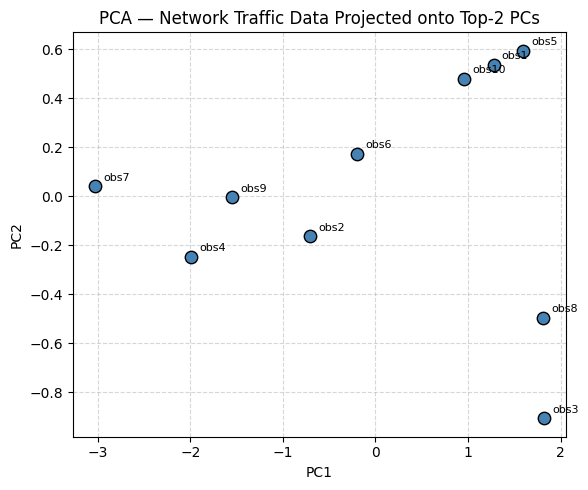


PCA scatter plot saved as task_4_3_pca.png


In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset: 10 observations of 3 network traffic features
X = np.array([
    [120, 15, 3], [135, 18, 4], [128, 12, 2], [142, 20, 5],
    [118, 14, 3], [130, 17, 4], [145, 22, 6], [125, 13, 2],
    [138, 19, 5], [122, 16, 3]
], dtype=float)

# ── (a) Standardise ──────────────────────────────────────────────
X_mean = np.mean(X, axis=0)
X_std_dev = np.std(X, axis=0, ddof=0)
X_std = (X - X_mean) / X_std_dev
print('(a) Standardised data (first 3 rows):')
print(np.round(X_std[:3], 4))
print('    Mean of standardised data:', np.round(np.mean(X_std, axis=0), 10))

# ── (b) Covariance matrix ─────────────────────────────────────────
cov = np.cov(X_std.T)   # shape (3, 3)
print('\n(b) Covariance matrix:')
print(np.round(cov, 4))

# ── (c) Eigenvalues & eigenvectors (sorted descending) ────────────
eigvals, eigvecs = np.linalg.eigh(cov)   # eigh for symmetric
idx = np.argsort(eigvals)[::-1]
eigvals  = eigvals[idx]
eigvecs  = eigvecs[:, idx]
print('\n(c) Eigenvalues (descending):', np.round(eigvals, 6))
print('    Eigenvectors (columns):')
print(np.round(eigvecs, 6))

# ── (d) Explained Variance Ratio ─────────────────────────────────
evr = eigvals / np.sum(eigvals)
cumulative_evr = np.cumsum(evr)
print('\n(d) Explained Variance Ratios:', np.round(evr, 6))
print('    Cumulative EVR:            ', np.round(cumulative_evr, 6))
n_components_95 = int(np.searchsorted(cumulative_evr, 0.95)) + 1
print(f'    Components needed for ≥95% variance: {n_components_95}')

# ── (e) Project onto top-2 PCs and scatter plot ───────────────────
X_pca = X_std @ eigvecs[:, :2]
print('\n(e) Projected data (top-2 PCs):')
print(np.round(X_pca, 4))

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='steelblue', edgecolors='k', s=80, zorder=3)
for i, (px, py) in enumerate(X_pca):
    plt.annotate(f'obs{i+1}', (px, py), textcoords='offset points',
                 xytext=(6, 4), fontsize=8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA — Network Traffic Data Projected onto Top-2 PCs')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('task_4_3_pca.png', dpi=100, bbox_inches='tight')
plt.show()
print('\nPCA scatter plot saved as task_4_3_pca.png')
